In [9]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import nltk

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [8]:
import kagglehub

path = kagglehub.dataset_download(
    "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews"
)

# Load CSV
df = pd.read_csv(os.path.join(path, "IMDB Dataset.csv"))

df.head()

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [11]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [12]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

In [13]:
df["clean_review"] = df["review"].apply(clean_text)

In [14]:
df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode ho...
1,A wonderful little production. <br /><br />The...,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake thinks zombie...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


In [15]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_review"])

In [16]:
encoder = LabelEncoder()

y = encoder.fit_transform(df["sentiment"])

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
model = LogisticRegression(max_iter=1000)

In [19]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [20]:
y_pred = model.predict(X_test)

In [21]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8921


In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [23]:
print(confusion_matrix(y_test, y_pred))

[[4357  604]
 [ 475 4564]]


In [24]:
review = input("Enter Movie Review: ")

review = clean_text(review)

review_vector = vectorizer.transform([review])

prediction = model.predict(review_vector)

print("Predicted Sentiment:", encoder.inverse_transform(prediction)[0])

Enter Movie Review: the movie was so good i loved the scene
Predicted Sentiment: positive


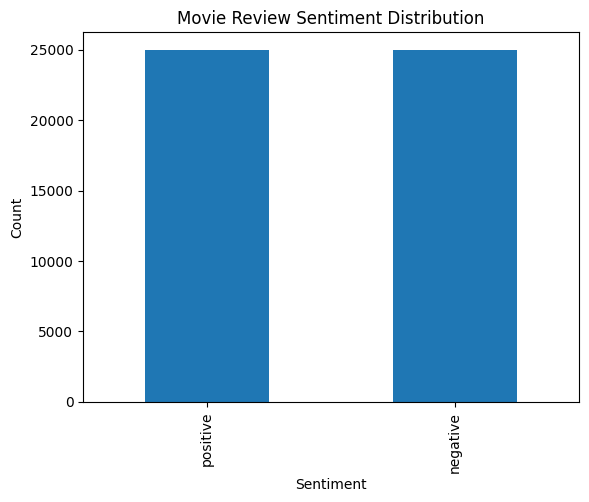

In [25]:
df["sentiment"].value_counts().plot(kind="bar")

plt.title("Movie Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [26]:
print(df["sentiment"].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64
